# **Guía de Actividades Práctico-Experimentales Nro. 013**

---

## **1. Datos Generales**

| **Atributo** | **Descripción** |
| :--- | :--- |
| **Estudiantes** | Kiara Condoy, Héctor Guerrero, Javier Guarnizo, Ricardo Ochoa, Emily Salas |
| **Asignatura** | Teoría de la Distribución y Probabilidad |
| **Ciclo** | 2do “A” |
| **Unidad** | 3 |
| **Práctica Nro.** | 014 |
| **Título de la Práctica** | **Modelado Probabilístico Avanzado: Regresión Logística, Clasificación Binaria y Matriz de Confusión**|
| **Nombre del Docente** | Cristian Ramiro Narváez Guillén |
| **Fecha** | Martes 21 de julio 2026 |

---


## **Tarea 1: Fundamentos de la Regresión Logística (Función Sigmoide)**

Optimization terminated successfully.
         Current function value: 0.366379
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Falla   No. Observations:                  200
Model:                          Logit   Df Residuals:                      198
Method:                           MLE   Df Model:                            1
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                  0.4676
Time:                        17:24:38   Log-Likelihood:                -73.276
converged:                       True   LL-Null:                       -137.63
Covariance Type:            nonrobust   LLR p-value:                 7.874e-30
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.6766      1.372     -7.785      0.000     -13.365      -7.988
Temp_CPU       0.1604      0.

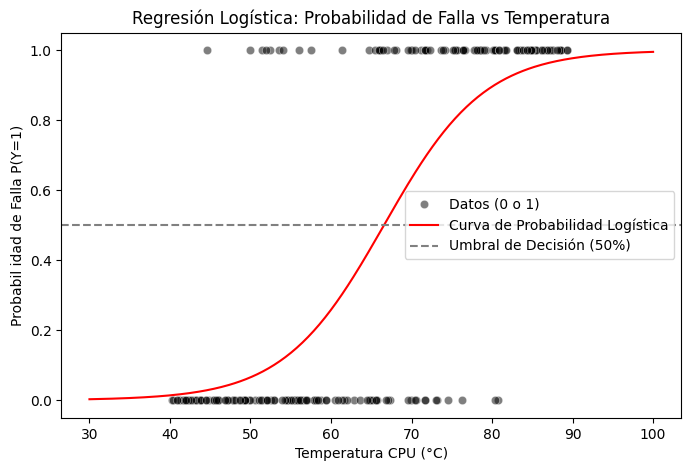

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Generación de datos simulados (Clasificación Binaria)
np.random.seed(42)
n_muestras = 200

# Variable predictora: Temperatura CPU (entre 40 y 90 grados)
temp_cpu = np.random.uniform(40, 90, size=n_muestras)
# Generar variable binaria probabilística (A mayor temperatura, mayor probabilidad de falla)
z = -10 + 0.15 * temp_cpu # Ecuación lineal (Log-Odds)
probabilidad_falla = 1 / (1 + np.exp(-z)) # Transformación Sigmoide

# Variable respuesta binaria (0 = OK, 1 = Falla) basada en la probabilidad
falla_servidor = np.random.binomial(1, p=probabilidad_falla)
df_sim = pd.DataFrame({'Temp_CPU': temp_cpu, 'Falla': falla_servidor})

# 2. Ajuste del Modelo Logístico (Logit)
X_log = sm.add_constant(df_sim['Temp_CPU'] )
Y_log = df_sim['Falla']

# Entrenamiento usando MLE (Maximum Likelihood Estimation)
modelo_logit = sm.Logit(Y_log, X_log).fit()
print(modelo_logit.summary())


# 3. Visualización de la Curva Sigmoide
x_rango = np.linspace(30, 100, 300)
x_rango_sm = sm.add_constant(x_rango)
y_pred_prob = modelo_logit.predict(x_rango_sm)

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Temp_CPU', y='Falla', data=df_sim, color='black', alpha=0.5, label='Datos (0 o 1)')
plt.plot(x_rango, y_pred_prob, color='red', label='Curva de Probabilidad Logística')
plt.axhline(0.5, color='gray', linestyle='--', label='Umbral de Decisión (50%)')
plt.title('Regresión Logística: Probabilidad de Falla vs Temperatura')
plt.xlabel('Temperatura CPU (°C)')
plt.ylabel('Probabil idad de Falla P(Y=1)')
plt.legend()
plt.show()


---
# **Tarea 2: Hito del Proyecto - Predicción Dicotómica Regional (ABP)**


In [ ]:
import pandas as pd
import numpy as np

# 1. Conexión a la nueva hoja del Spreadsheet
url = 'https://docs.google.com/spreadsheets/d/1E-rrTgcTIWS-UnuVf1ldKvhDkwT6uUgh/export?format=xlsx'

try:
    # Nombre exacto de la pestaña
    df = pd.read_excel(url, sheet_name='Subnational 1 tree cover loss')

    # Limpieza básica
    df = df.dropna(how='all').reset_index(drop=True)
    print("¡Conexión exitosa a la hoja de Provincias!")

except Exception as e:
    print(f"Error: {e}")

¡Conexión exitosa a la hoja de Provincias!


In [ ]:
import statsmodels.api as sm

# 1. Seleccionar una variable continua de interés y binarizarla
# Usaremos 'tc_loss_ha_2024' del DataFrame 'df' para usar los datos más actuales.

# Calcular la media de la variable continua
mean_tree_loss = df['tc_loss_ha_2024'].mean()

# Crear la nueva columna binaria 'High_Tree_Loss'
df['High_Tree_Loss'] = (df['tc_loss_ha_2024'] > mean_tree_loss).astype(int)

print(f"Media de 'tc_loss_ha_2024': {mean_tree_loss:.2f}")
print(f"Distribución de la variable binaria 'High_Tree_Loss':\n{df['High_Tree_Loss'].value_counts()}")

# 2. Seleccionar al menos dos variables predictoras
predictor_vars = ['extent_2000_ha', 'area_ha']

X = df[predictor_vars]
Y = df['High_Tree_Loss']

# Añadir una constante al modelo para el intercepto
X = sm.add_constant(X)

# 3. Ajustar el modelo sm.Logit()
# Eliminar filas con NaN en X o Y, si las hubiera, antes de ajustar el modelo
df_model = pd.concat([X, Y], axis=1).dropna()
X_model = df_model[X.columns]
Y_model = df_model['High_Tree_Loss']

modelo_logit_new = sm.Logit(Y_model, X_model).fit()

# 4. Imprimir el resumen del modelo
print("\nResumen del Modelo de Regresión Logística:")
print(modelo_logit_new.summary())

Media de 'tc_loss_ha_2024': 2585.36
Distribución de la variable binaria 'High_Tree_Loss':
High_Tree_Loss
0    141
1     51
Name: count, dtype: int64
Optimization terminated successfully.
         Current function value: 0.156411
         Iterations 9

Resumen del Modelo de Regresión Logística:
                           Logit Regression Results                           
Dep. Variable:         High_Tree_Loss   No. Observations:                  192
Model:                          Logit   Df Residuals:                      189
Method:                           MLE   Df Model:                            2
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                  0.7298
Time:                        17:29:52   Log-Likelihood:                -30.031
converged:                       True   LL-Null:                       -111.14
Covariance Type:            nonrobust   LLR p-value:                 5.948e-36
                     coef    std err          z      P>|z|      [0.025   

A partir de los resultados del modelo de regresión logística (`modelo_logit_new.summary()`):

Las variables que incrementan estadísticamente la probabilidad de que ocurra el evento (es decir, que la pérdida de cobertura arbórea sea alta, `High_Tree_Loss`) son aquellas con un coeficiente positivo y un valor-p (P>|z|) inferior a 0.05.

Ambas variables predictoras cumplen con estos criterios:

-   **`extent_2000_ha`**:
    -   Coeficiente (coef): `2.496e-06` (positivo)
    -   Valor-p (P>|z|): `0.014` (menor que 0.05)

-   **`area_ha`**:
    -   Coeficiente (coef): `3.245e-06` (positivo)
    -   Valor-p (P>|z|): `0.005` (menor que 0.05)

Por lo tanto, tanto `extent_2000_ha` como `area_ha` son variables que incrementan significativamente la probabilidad de una alta pérdida de cobertura arbórea.

---
# **Tarea 3: Evaluación del Modelo (Matriz de Confusión)**



--- Evaluación del Modelo Probabilístico ---
Exactitud Global (Accuracy): 84.00%


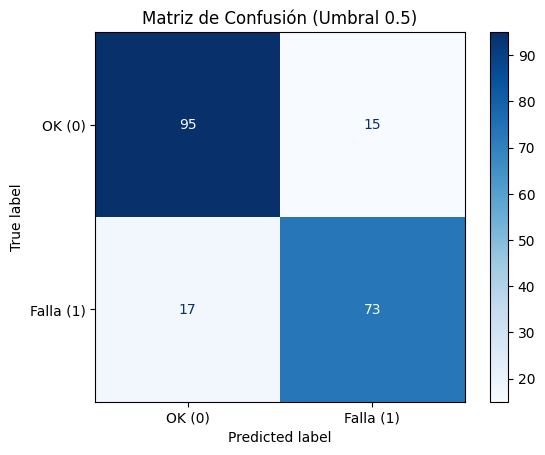

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# El modelo devuelve probabilidades continuas [0, 1] . Debemos convertirlas a 0 o 1
# usando un umbral (threshold) estándar de 0.5 (50%)
probabilidades = modelo_logit.predict(X_log)
predicciones_clase = (probabilidades >= 0.5).astype(int)

# Cálculo de la Matriz de Confusión
cm = confusion_matrix(Y_log, predicciones_clase)
exactitud = accuracy_score(Y_log, predicciones_clase)

print(f"\n--- Evaluación del Modelo Probabilístico ---")
print(f"Exactitud Global (Accuracy): {exactitud*100:.2f}%")

# Visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['OK (0)', 'Falla (1)'] )
disp.plot(cmap='Blues', values_format='d')

plt.title('Matriz de Confusión (Umbral 0.5)')
plt.show()


---
# **Tarea 4: ABI - El Análisis del Umbral (Thresholding) y Falsos Positivos**

### 1. Investigación: Cómo alterar el umbral modifica la Matriz de Confusión

El umbral de decisión en un modelo de clasificación binaria es el punto a partir del cual una probabilidad predicha se convierte en una clase binaria (0 o 1). Tradicionalmente, se usa un umbral de 0.5, lo que significa que si la probabilidad predicha de que un evento ocurra es del 50% o más, se clasifica como 1; de lo contrario, como 0.

Alterar este umbral tiene un impacto directo en los elementos de la Matriz de Confusión:

*   **Aumentar el Umbral (ej. de 0.5 a 0.7):** Hace que el modelo sea más estricto para clasificar un caso como positivo (1). Esto generalmente conduce a:
    *   **Menos Falsos Positivos (FP):** Se reduce la cantidad de casos que el modelo predice incorrectamente como 1 cuando en realidad son 0.
    *   **Más Falsos Negativos (FN):** Se aumenta la cantidad de casos que el modelo predice incorrectamente como 0 cuando en realidad son 1 (ya que ahora requiere una probabilidad más alta para ser clasificado como 1).
    *   **Mayor Especificidad:** La capacidad del modelo para identificar correctamente los negativos (0) mejora.
    *   **Menor Sensibilidad:** La capacidad del modelo para identificar correctamente los positivos (1) disminuye.

*   **Disminuir el Umbral (ej. de 0.5 a 0.2):** Hace que el modelo sea más laxo para clasificar un caso como positivo (1). Esto generalmente conduce a:
    *   **Más Falsos Positivos (FP):** Se aumenta la cantidad de casos que el modelo predice incorrectamente como 1 cuando en realidad son 0.
    *   **Menos Falsos Negativos (FN):** Se reduce la cantidad de casos que el modelo predice incorrectamente como 0 cuando en realidad son 1.
    *   **Menor Especificidad:** La capacidad del modelo para identificar correctamente los negativos (0) disminuye.
    *   **Mayor Sensibilidad:** La capacidad del modelo para identificar correctamente los positivos (1) mejora.

La elección del umbral depende críticamente del contexto y de los costos relativos de los errores (Falsos Positivos vs. Falsos Negativos). En escenarios donde un Falso Negativo es muy costoso (como no detectar una falla crítica), se prefiere un umbral más bajo para aumentar la sensibilidad, aunque esto implique más Falsos Positivos.

--- Matriz de Confusión (Umbral 0.5) para el modelo regional ---
Verdaderos Negativos (TN): 133
Falsos Positivos (FP): 8
Falsos Negativos (FN): 10
Verdaderos Positivos (TP): 41


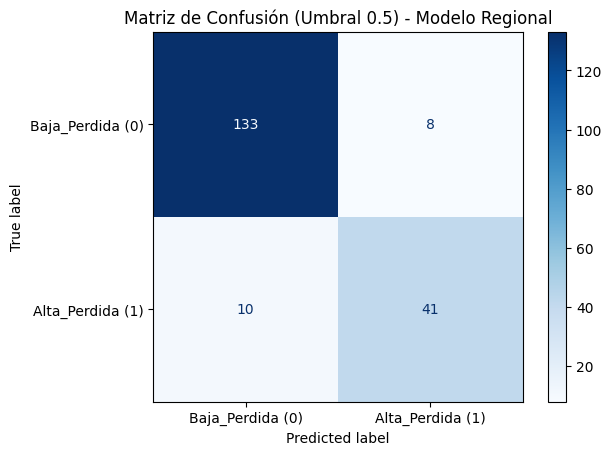

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Matriz de Confusión para el modelo regional (modelo_logit_new) con umbral 0.5 (Línea Base) ---

# Obtener las probabilidades predichas para el modelo regional
probabilidades_new = modelo_logit_new.predict(X_model)

# Clasificación con umbral de 0.5
predicciones_clase_0_5 = (probabilidades_new >= 0.5).astype(int)

# Calcular la Matriz de Confusión
cm_0_5 = confusion_matrix(Y_model, predicciones_clase_0_5)

print("--- Matriz de Confusión (Umbral 0.5) para el modelo regional ---")
print(f"Verdaderos Negativos (TN): {cm_0_5[0, 0]}")
print(f"Falsos Positivos (FP): {cm_0_5[0, 1]}")
print(f"Falsos Negativos (FN): {cm_0_5[1, 0]}")
print(f"Verdaderos Positivos (TP): {cm_0_5[1, 1]}")

disp_0_5 = ConfusionMatrixDisplay(confusion_matrix=cm_0_5, display_labels=['Baja_Perdida (0)', 'Alta_Perdida (1)'])
disp_0_5.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión (Umbral 0.5) - Modelo Regional')
plt.show()


--- Matriz de Confusión (Umbral 0.20) para el modelo regional ---
Verdaderos Negativos (TN): 129
Falsos Positivos (FP): 12
Falsos Negativos (FN): 1
Verdaderos Positivos (TP): 50


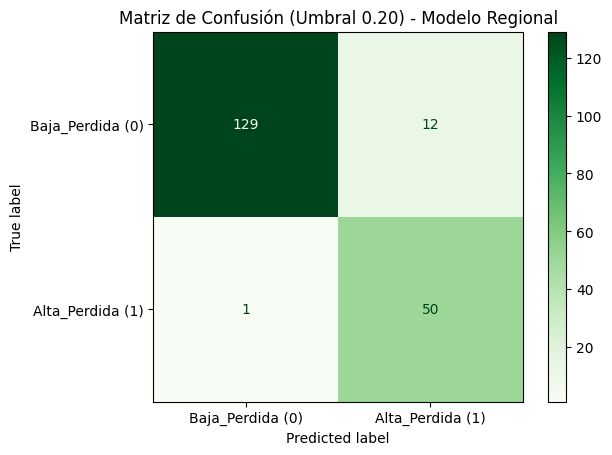

In [ ]:
# --- 2. Recalcular la Matriz de Confusión con Umbral 0.20 ---

# Clasificación con un umbral más conservador de 0.20
# (clasificar como 'Alta Pérdida' si la probabilidad es > 0.20)
predicciones_clase_0_2 = (probabilidades_new >= 0.2).astype(int)

# Calcular la nueva Matriz de Confusión
cm_0_2 = confusion_matrix(Y_model, predicciones_clase_0_2)

print("\n--- Matriz de Confusión (Umbral 0.20) para el modelo regional ---")
print(f"Verdaderos Negativos (TN): {cm_0_2[0, 0]}")
print(f"Falsos Positivos (FP): {cm_0_2[0, 1]}")
print(f"Falsos Negativos (FN): {cm_0_2[1, 0]}")
print(f"Verdaderos Positivos (TP): {cm_0_2[1, 1]}")

disp_0_2 = ConfusionMatrixDisplay(confusion_matrix=cm_0_2, display_labels=['Baja_Perdida (0)', 'Alta_Perdida (1)'])
disp_0_2.plot(cmap='Greens', values_format='d')
plt.title('Matriz de Confusión (Umbral 0.20) - Modelo Regional')
plt.show()

### 3. Análisis de Falsos Positivos vs. Falsos Negativos y Recomendación de Umbral

**Análisis de lo sucedido con Falsos Positivos (FP) y Falsos Negativos (FN):**

Al comparar las matrices de confusión con umbrales de 0.5 y 0.2 para el modelo regional (`modelo_logit_new`):

**Umbral 0.5:**
*   **Falsos Positivos (FP):** `8`
*   **Falsos Negativos (FN):** `10`

**Umbral 0.2:**
*   **Falsos Positivos (FP):** `12`
*   **Falsos Negativos (FN):** `1`

Observamos que al **disminuir el umbral de 0.5 a 0.2:**
*   Los **Falsos Positivos (FP) han aumentado de 8 a 12.** Esto significa que el modelo ahora clasifica más instancias como 'Alta Pérdida de Cobertura Arbórea' (1) cuando en realidad son 'Baja Pérdida' (0). El modelo se vuelve menos selectivo.
*   Los **Falsos Negativos (FN) han disminuido drásticamente de 10 a 1.** Esto indica que el modelo es ahora más eficaz para identificar los casos reales de 'Alta Pérdida de Cobertura Arbórea' (1), reduciendo el riesgo de pasar por alto situaciones problemáticas.

Este es el trade-off clásico: para reducir los Falsos Negativos (y aumentar la sensibilidad), generalmente se incurre en un aumento de los Falsos Positivos (disminuyendo la especificidad).

**Recomendación de Umbral (0.50 vs. 0.20) para Políticas Públicas o de Ingeniería:**

La elección del umbral depende críticamente del costo relativo de los errores en el contexto de su "proyecto regional" (predicción de `High_Tree_Loss`). El problema de la "pérdida de cobertura arbórea" tiene implicaciones ambientales y socioeconómicas significativas.

*   **Costo de un Falso Negativo (FN - No detectar alta pérdida, cuando sí la hay):** Si el modelo predice 'Baja Pérdida' (0) pero en realidad es 'Alta Pérdida' (1), las consecuencias podrían ser graves: destrucción de ecosistemas, pérdida de biodiversidad, desertificación, impacto en comunidades locales, etc. **El costo de un Falso Negativo en este escenario es extremadamente alto.** No actuar a tiempo puede llevar a daños irreversibles.

*   **Costo de un Falso Positivo (FP - Detectar alta pérdida, cuando no la hay):** Si el modelo predice 'Alta Pérdida' (1) pero en realidad es 'Baja Pérdida' (0), las consecuencias serían, por ejemplo: enviar equipos de monitoreo o implementar políticas de conservación en áreas que no lo necesitan con tanta urgencia, generando un gasto innecesario de recursos o una falsa alarma. Aunque indeseable, **el costo de un Falso Positivo, aunque puede ser significativo en términos de recursos, es generalmente menor que el de un Falso Negativo catastrófico.**

**Conclusión y Recomendación:**

Dada la naturaleza crítica de la conservación de la cobertura arbórea y las graves implicaciones de no detectar a tiempo una alta pérdida, **recomendaría el umbral más bajo de 0.20.**

Este umbral, al priorizar la reducción de los Falsos Negativos, asegura que se capturen la mayor cantidad posible de eventos de 'Alta Pérdida de Cobertura Arbórea', incluso si esto implica investigar algunas áreas donde la pérdida no es tan severa (Falsos Positivos). Es una estrategia conservadora que busca **minimizar el riesgo de daño ambiental significativo**, alineándose con la política de "mejor prevenir que lamentar" en contextos de gestión de recursos naturales y ambientales.

---
# **8. Conclusiones**

---

### 1. Del determinismo a la graduación de la incertidumbre

Tanto el uso de **Log-Odds** como la **predicción probabilística continua** demuestran que los modelos logísticos no buscan clasificar categorías de forma rígida, sino modelar la probabilidad subyacente.

Al pasar de un espacio acotado a una escala lineal continua, el modelo conserva la cuantificación de la incertidumbre, evitando tomar decisiones binarias a ciegas y permitiendo priorizar recursos y evaluar riesgos con mayor finura.

---

### 2. Criterios de evaluación adaptados a la naturaleza del fenómeno

La transición del $R^2$ tradicional al **Pseudo $R^2$ de McFadden** responde al cambio fundamental en el objetivo del análisis: en fenómenos binarios no se minimizan distancias de error cuadrático, sino que se **maximiza la verosimilitud** de los eventos observados.

Medir el ajuste en estos modelos exige métricas que entiendan la estructura estocástica del dato y no forzar herramientas concebidas para variables continuas.

---

### 3. La toma de decisiones como compromiso técnico y ético

La elección del umbral de corte ($k$) y la gestión de la *"zona gris"* ($p \approx 0.5$) trasladan la estadística al terreno de las decisiones reales.

Elegir entre **sensibilidad** y **especificidad** no es un cálculo puramente matemático, sino un balance de costos asimétricos y responsabilidad ética, donde la configuración del modelo refleja qué tipo de error (falso positivo o falso negativo) resulta más aceptable en el dominio de aplicación.

# **Respuestas a las Preguntas de Control y Reflexión Crítica**

---

> **¿Cuál es la esencia matemática de transformar una probabilidad en Log-Odds, y por qué este cambio de dominio es fundamental para el entendimiento de la causalidad probabilística?**

La transformación de probabilidad a Log-Odds (función *logit*) sigue dos pasos:

1. **Odds:** $\text{Odds} = \frac{p}{1-p}$, que lleva el intervalo $(0,1)$ a $[0, +\infty)$.
2. **Logit:** $\text{logit}(p) = \ln\left(\frac{p}{1-p}\right)$, que extiende el dominio al conjunto completo de los números reales $(-\infty, +\infty)$.

Esto es crucial porque:
* En la escala de Log-Odds, los predictores actúan de manera **aditiva y lineal**, lo que permite interpretar efectos constantes.
* Los coeficientes del modelo logístico, al exponenciarse, se convierten en **Odds Ratios**, los cuales cuantifican el impacto causal de un factor sin violar los límites de probabilidad $[0, 1]$.

---

>**¿Por qué la naturaleza del fenómeno (binario) nos obliga a abandonar la medida clásica de bondad de ajuste (R²) y adoptar el Pseudo R² de McFadden, y qué nos dice este cambio sobre la relación entre la realidad y la medición?**

En regresión lineal, el $R^2$ mide la proporción de varianza explicada. Sin embargo, en fenómenos binarios:
* Los residuos no son normales ni tienen varianza constante: $\text{Var}(Y|X) = p(1-p)$.
* La noción de *"distancia euclidiana"* pierde sentido porque los datos observados son únicamente $0$ o $1$.

El **Pseudo $R^2$ de McFadden** se basa en verosimilitudes:

$$R^2_{\text{McFadden}} = 1 - \frac{\ln L_{\text{modelo}}}{\ln L_{\text{nulo}}}$$

Esto refleja que en contextos binarios no buscamos minimizar distancias, sino **maximizar la plausibilidad estadística** de los datos observados. La medición se adapta a la naturaleza discreta de la realidad.

---

>**Ante un caso de incertidumbre total (predicción 0.5), ¿de qué manera la estructura del modelo intenta forzar una decisión binaria, y qué riesgos enfrentamos al ignorar la zona gris de la probabilidad?**

Cuando $p = 0.5$, el sistema se encuentra en **máxima entropía** (incertidumbre total). Sin embargo, el modelo suele imponer un umbral rígido (por defecto $k = 0.5$) para clasificar:
* $p \ge 0.5 \longrightarrow \text{Clase 1}$
* $p < 0.5 \longrightarrow \text{Clase 0}$

**Riesgos de ignorar la zona gris:**
* **Falsa certeza:** Casos con $p = 0.499$ y $p = 0.501$ reciben etiquetas opuestas pese a ser prácticamente idénticos.
* **Fragilidad:** Pequeñas variaciones de ruido pueden cambiar drásticamente la decisión.
* **Pérdida de gestión del riesgo:** En ámbitos críticos (medicina, finanzas), los casos intermedios deberían derivarse a revisión humana o adicional, no a una clasificación automática.

---

>**¿Cuál es el conflicto esencial entre la sensibilidad y la especificidad, y cómo la elección de un umbral refleja los valores éticos y técnicos subyencentes en una decisión de ingeniería?**

El conflicto surge porque:
* **Sensibilidad (TPR):** Detecta positivos, minimiza falsos negativos.
* **Especificidad (TNR):** Detecta negativos, minimiza falsos positivos.

Mover el umbral altera directamente este balance:
* **Umbral bajo:** Mayor sensibilidad, menor especificidad.
* **Umbral alto:** Mayor especificidad, menor sensibilidad.

La elección del umbral refleja valores éticos y técnicos:
* **Medicina (ej. diagnóstico de cáncer):** Se prioriza la **sensibilidad** para evitar falsos negativos a toda costa.
* **Detección de Spam:** Se prioriza la **especificidad** para evitar clasificar un correo importante como spam (falso positivo).
* **Créditos financieros:** Se busca un balance según el apetito de riesgo de la entidad.

*En resumen, el umbral no es un parámetro puramente estadístico, sino una decisión ética y económica.*

---

>**¿Cuál es el propósito final de predecir probabilidades en lugar de estados binarios rígidos, y cómo esta distinción transforma nuestra capacidad de intervenir en la realidad?**

El propósito es **preservar la incertidumbre cuantificada**:
1. Permite **priorizar y ordenar** casos en un ranking continuo (ej. atender primero a los pacientes de mayor riesgo).
2. **Desacopla el modelo de las reglas de negocio:** El modelo estima probabilidades y las decisiones finales se ajustan posteriormente según costos, políticas o restricciones.
3. Facilita la **calibración del riesgo** mediante valores esperados:

$$\text{Valor Esperado} = p \cdot (\text{Beneficio}) - (1 - p) \cdot (\text{Coste})$$

Así, el modelo deja de actuar como un juez categórico rígido y se convierte en una **herramienta flexible de intervención bajo incertidumbre**, ampliando nuestra capacidad de actuar estratégicamente en la realidad.
